<a href="https://colab.research.google.com/github/dfreyes/m2t4/blob/main/m2t4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Taller: Adquisición, procesamiento y visualización de datos

---

###Objetivos del Proyecto
1.   Algoritmos de aprendizaje automático: Utilizar algoritmos de aprendizaje
automático para el análisis de datos de comercio
2.   Clasificación de clientes: Clasificación de clientes en varias categorías.
3.   Segmentación de Clientes: Utilizar técnicas de agrupamiento para segmentar
a los clientes basándose en su comportamiento de compra.
4.   Predicción de Ventas: Desarrollar un modelo predictivo para pronosticar ventas futuras basándose en datos históricos.
---

###Fundamentos de ciencia de datos
Modulo 2 Taller 2
|   |   |
| :--- | :--- |
| **Autor:** | Ing. Diego F. Reyes Y. |
| **Fecha:** | Octubre 2026 |
| **Fuente de Datos:** | https://archive.ics.uci.edu/ml/datasets/Online+Retail+II *(Online Retail Data Set)* |
---

# Parte 0: Preparación
---

## Exploración y limpieza de Datos
*   Descargar el conjunto de datos Online Retail II.
*   Cargar el conjunto de datos utilizando pandas y realizar una exploración
inicial para entender la estructura y contenido de los datos.
*   Limpiar los datos manejando valores faltantes, eliminando registros
duplicados y filtrando entradas irrelevantes (por ejemplo, transacciones
sin ID de clientes o pedidos cancelados).


### Importar libreria

In [ ]:
# Importar libreria
import pandas as pd

### Adquisicion de datos

In [ ]:

# Adquision de datos
print(" • " * 20)
print(" Recuerde cargar el set de datos antes de usar el codigo ")
print(" El nombre es online_retail_II.xlsx ")
print(" • " * 20)

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
 Recuerde cargar el set de datos antes de usar el codigo 
 El nombre es online_retail_II.xlsx 
 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 


In [ ]:
print(" • " * 20)
print(f"\033[1mLectura del archivo de datos a traves de la importacion de la libreria\033[0m")
# Lee el archivo Excel
# df = pd.read_excel('online_retail_II.xlsx')
# Muestra las primeras 5 filas para verificar el contenido
# df.head()


import pandas as pd

# 1. Cargar la primera hoja (Año 2009-2010)
df_periodo1 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')

# 2. Cargar la segunda hoja (Año 2010-2011)
df_periodo2 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

# 3. Concatenar verticalmente ambas hojas en un único DataFrame unificado
df = pd.concat([df_periodo1, df_periodo2], ignore_index=True)

print("=== VERIFICACIÓN DE LA UNIÓN ===")
print(f"Registros combinados totales: {df.shape[0]:,}")
print(f"Rango real de fechas: desde {df['InvoiceDate'].min()} hasta {df['InvoiceDate'].max()}")
df.head()


 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Lectura del archivo de datos a traves de la importacion de la libreria
=== VERIFICACIÓN DE LA UNIÓN ===
Registros combinados totales: 1,067,371
Rango real de fechas: desde 2009-12-01 07:45:00 hasta 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### Metadato


| Variable Name | Role | Type | Description | Units | Missing Values |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **InvoiceNo** | ID | Categorical | a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation | | no |
| **StockCode** | ID | Categorical | a 5-digit integral number uniquely assigned to each distinct product | | no |
| **Description** | Feature | Categorical | product name | | no |
| **Quantity** | Feature | Integer | the quantities of each product (item) per transaction | | no |
| **InvoiceDate** | Feature | Date | the day and time when each transaction was generated | | no |
| **UnitPrice** | Feature | Continuous | product price per unit | sterling | no |
| **CustomerID** | Feature | Categorical | a 5-digit integral number uniquely assigned to each customer | | no |
| **Country** | Feature | Categorical | the name of the country where each customer resides | | no |


### Descripcion de los datos

In [ ]:
print(df.shape)

(1067371, 8)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice,1067371.0,53628.0,537434.0,1350.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1067371.0,NaN,NaN,NaN,9.938898,-80995.0,1.0,3.0,10.0,80995.0,172.705794
InvoiceDate,1067371,NaN,NaN,NaN,2011-01-02 21:13:55.394028544,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,1067371.0,NaN,NaN,NaN,4.649388,-53594.36,1.25,2.1,4.15,38970.0,123.553059
Customer ID,824364.0,NaN,NaN,NaN,15324.638504,12346.0,13975.0,15255.0,16797.0,18287.0,1697.46445
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Eliminar orden cancelada

In [ ]:
df = df[~df['Invoice'].astype(str).str.contains('^C', case=False, na=False)]
print(df.shape)

(1047877, 8)


### Eliminar duplicados

In [ ]:
# Contar el total de registros duplicados
print(df.duplicated().sum())

33945


In [ ]:
print(df[df.duplicated()])

        Invoice StockCode                        Description  Quantity  \
371      489517     21912           VINTAGE SNAKES & LADDERS         1   
383      489517     22130   PARTY CONE CHRISTMAS DECORATION          6   
384      489517     22319  HAIRCLIPS FORTIES FABRIC ASSORTED        12   
385      489517     21913     VINTAGE SEASIDE JIGSAW PUZZLES         1   
386      489517     21821   GLITTER STAR GARLAND WITH BELLS          1   
...         ...       ...                                ...       ...   
1067136  581538     22068        BLACK PIRATE TREASURE CHEST         1   
1067150  581538     23318     BOX OF 6 MINI VINTAGE CRACKERS         1   
1067153  581538     22992             REVOLVER WOODEN RULER          1   
1067160  581538     22694                       WICKER STAR          1   
1067162  581538     23343       JUMBO BAG VINTAGE CHRISTMAS          1   

                InvoiceDate  Price  Customer ID         Country  
371     2009-12-01 11:34:00   3.75      16329

In [ ]:
# Eliminar los duplicados idénticos y actualizar el DataFrame
df = df.drop_duplicates()
# Contar el total de registros duplicados
print(df.duplicated().sum())


0


### Eliminar valores faltantes

In [ ]:
print(df.isnull().sum().sum())
print((df.isnull().sum() / len(df)) * 100)

238712
Invoice         0.000000
StockCode       0.000000
Description     0.421626
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    23.121570
Country         0.000000
dtype: float64


In [ ]:
# 1. Eliminar filas sin ID de cliente o sin descripción
df = df.dropna(subset=['Customer ID', 'Description'])
print(df.isnull().sum().sum())
print((df.isnull().sum() / len(df)) * 100)

0
Invoice        0.0
StockCode      0.0
Description    0.0
Quantity       0.0
InvoiceDate    0.0
Price          0.0
Customer ID    0.0
Country        0.0
dtype: float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779495 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779495 non-null  object        
 1   StockCode    779495 non-null  object        
 2   Description  779495 non-null  object        
 3   Quantity     779495 non-null  int64         
 4   InvoiceDate  779495 non-null  datetime64[ns]
 5   Price        779495 non-null  float64       
 6   Customer ID  779495 non-null  float64       
 7   Country      779495 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 53.5+ MB


### Definicion de formato de variable

In [ ]:
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779495 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779495 non-null  object        
 1   StockCode    779495 non-null  object        
 2   Description  779495 non-null  object        
 3   Quantity     779495 non-null  int64         
 4   InvoiceDate  779495 non-null  datetime64[ns]
 5   Price        779495 non-null  float64       
 6   Customer ID  779495 non-null  object        
 7   Country      779495 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 53.5+ MB


### Creacion de variable monto


In [ ]:
# Crear la columna de Monto Total (Venta por registro)
df['Total_Amount'] = df['Quantity'] * df['Price']
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779495 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Invoice       779495 non-null  object        
 1   StockCode     779495 non-null  object        
 2   Description   779495 non-null  object        
 3   Quantity      779495 non-null  int64         
 4   InvoiceDate   779495 non-null  datetime64[ns]
 5   Price         779495 non-null  float64       
 6   Customer ID   779495 non-null  object        
 7   Country       779495 non-null  object        
 8   Total_Amount  779495 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 59.5+ MB


### Eliminar codigos que no sean de cinco digitos numericos o que no esten acompañados de una letra

In [ ]:
import pandas as pd

# 1. Definir el patrón correcto
patron_valido = r'^\d{5}[a-zA-Z]*$'

# 2. Crear una máscara booleana (True para válidos, False para los "extraños")
es_valido = df['StockCode'].astype(str).str.contains(patron_valido, na=False)

# 3. Calcular el Monto de cada transacción (si aún no lo habías creado)
if 'Total_Amount' not in df.columns:
    df['Total_Amount'] = df['Quantity'] * df['Price']

# 4. Calcular estadísticas de volumen (filas)
total_filas = len(df)
filas_no_validas = len(df[~es_valido])
porcentaje_filas = (filas_no_validas / total_filas) * 100

# 5. Calcular estadísticas financieras (dinero)
dinero_total = df['Total_Amount'].sum()
dinero_no_valido = df[~es_valido]['Total_Amount'].sum()
porcentaje_dinero = (dinero_no_valido / dinero_total) * 100

# 6. Imprimir el reporte estadístico
print("=== REPORTE ESTADÍSTICO DE REGISTROS NO VÁLIDOS ===")
print(f"Total de filas en el DataFrame actual: {total_filas:,}")
print(f"Filas que NO cumplen el patrón:        {filas_no_validas:,} ({porcentaje_filas:.3f}%)")
print("-" * 50)
print(f"Monto financiero total actual:         {dinero_total:,.2f}")
print(f"Monto de los registros NO válidos:     {dinero_no_valido:,.2f} ({porcentaje_dinero:.3f}%)")
print("=" * 51)

# 7. Mostrar el Top 10 de StockCodes extraños que más dinero o ruido generan
print("\nTop 10 StockCodes fuera del patrón que más registros tienen:")
print(df[~es_valido]['StockCode'].value_counts().head(10))


=== REPORTE ESTADÍSTICO DE REGISTROS NO VÁLIDOS ===
Total de filas en el DataFrame actual: 779,495
Filas que NO cumplen el patrón:        2,858 (0.367%)
--------------------------------------------------
Monto financiero total actual:         17,374,804.27
Monto de los registros NO válidos:     306,236.30 (1.763%)

Top 10 StockCodes fuera del patrón que más registros tienen:
StockCode
POST            1803
M                688
C2               248
ADJUST            32
BANK CHARGES      31
PADS              18
DOT               16
TEST001           11
D                  5
ADJUST2            3
Name: count, dtype: int64


In [ ]:
import pandas as pd

# 1. Crear un DataFrame de diagnóstico basado en la columna StockCode
df_test = pd.DataFrame({'StockCode': df['StockCode'].astype(str).unique()})

# 2. Extraer propiedades de cada código único
df_test['Longitud'] = df_test['StockCode'].str.len()
df_test['Es_Numerico_Puro'] = df_test['StockCode'].str.isnumeric()
df_test['Es_Letras_Puro'] = df_test['StockCode'].str.isalpha()

# 3. Identificar la "Forma" del código reemplazando números por 'N' y letras por 'L'
# Ejemplo: '79323P' se convierte en 'NNNNNL', 'POST' en 'LLLL'
df_test['Forma_Estructural'] = df_test['StockCode'].str.replace(r'\d', 'N', regex=True).str.replace(r'[a-zA-Z]', 'L', regex=True)

# 4. Unir de regreso al DataFrame original para contar la frecuencia real de uso (filas)
df_estructuras = df[['StockCode']].astype(str).merge(df_test, on='StockCode', how='left')

# 5. Agrupar para ver el reporte de las estructuras dominantes en tu negocio
reporte = df_estructuras.groupby(['Forma_Estructural', 'Longitud', 'Es_Numerico_Puro', 'Es_Letras_Puro']).size().reset_index(name='Frecuencia_Filas')
reporte['Porcentaje_%'] = (reporte['Frecuencia_Filas'] / len(df)) * 100
reporte = reporte.sort_values(by='Frecuencia_Filas', ascending=False)

print("=== REPORTE DE DESCUBRIMIENTO DE ESTRUCTURAS DE DATOS ===")
print(reporte.to_string(index=False, formatters={'Frecuencia_Filas': '{:,}'.format, 'Porcentaje_%': '{:.3f}%'.format}))


=== REPORTE DE DESCUBRIMIENTO DE ESTRUCTURAS DE DATOS ===
Forma_Estructural  Longitud  Es_Numerico_Puro  Es_Letras_Puro Frecuencia_Filas Porcentaje_%
            LLLLL         5              True           False          690,646      88.602%
           LLLLLL         6             False           False           84,959      10.899%
             LLLL         4             False            True            1,821       0.234%
          LLLLLLL         7             False           False            1,049       0.135%
                L         1             False            True              693       0.089%
               LL         2             False           False              248       0.032%
           LLLLLL         6             False            True               32       0.004%
     LLLL LLLLLLL        12             False           False               31       0.004%
              LLL         3             False            True               16       0.002%


In [ ]:
print(df.shape)

(779495, 9)


In [ ]:
# Filtro
patron_definitivo = r'^\d{5}[a-zA-Z]*$'
df = df[df['StockCode'].astype(str).str.contains(patron_definitivo, na=False)]
print(f"Total de registros: {len(df):,}")

Total de registros: 776,637


In [ ]:
import pandas as pd

# 1. Crear un DataFrame de diagnóstico basado en la columna StockCode
df_test = pd.DataFrame({'StockCode': df['StockCode'].astype(str).unique()})

# 2. Extraer propiedades de cada código único
df_test['Longitud'] = df_test['StockCode'].str.len()
df_test['Es_Numerico_Puro'] = df_test['StockCode'].str.isnumeric()
df_test['Es_Letras_Puro'] = df_test['StockCode'].str.isalpha()

# 3. Identificar la "Forma" del código reemplazando números por 'N' y letras por 'L'
# Ejemplo: '79323P' se convierte en 'NNNNNL', 'POST' en 'LLLL'
df_test['Forma_Estructural'] = df_test['StockCode'].str.replace(r'\d', 'N', regex=True).str.replace(r'[a-zA-Z]', 'L', regex=True)

# 4. Unir de regreso al DataFrame original para contar la frecuencia real de uso (filas)
df_estructuras = df[['StockCode']].astype(str).merge(df_test, on='StockCode', how='left')

# 5. Agrupar para ver el reporte de las estructuras dominantes en tu negocio
reporte = df_estructuras.groupby(['Forma_Estructural', 'Longitud', 'Es_Numerico_Puro', 'Es_Letras_Puro']).size().reset_index(name='Frecuencia_Filas')
reporte['Porcentaje_%'] = (reporte['Frecuencia_Filas'] / len(df)) * 100
reporte = reporte.sort_values(by='Frecuencia_Filas', ascending=False)

print("=== REPORTE DE DESCUBRIMIENTO DE ESTRUCTURAS DE DATOS ===")
print(reporte.to_string(index=False, formatters={'Frecuencia_Filas': '{:,}'.format, 'Porcentaje_%': '{:.3f}%'.format}))


=== REPORTE DE DESCUBRIMIENTO DE ESTRUCTURAS DE DATOS ===
Forma_Estructural  Longitud  Es_Numerico_Puro  Es_Letras_Puro Frecuencia_Filas Porcentaje_%
            LLLLL         5              True           False          690,646      88.928%
           LLLLLL         6             False           False           84,957      10.939%
          LLLLLLL         7             False           False            1,034       0.133%


In [ ]:
# Filtrar y ver qué productos tienen exactamente longitud 7
longitud_7 = df[df['StockCode'].astype(str).str.len() == 7]
print(longitud_7[['StockCode', 'Description']].drop_duplicates().head(20))

     StockCode               Description
572    79323LP  LIGHT PINK CHERRY LIGHTS
613    15056BL   EDWARDIAN PARASOL BLACK
3173   79323GR       GREEN CHERRY LIGHTS


In [ ]:
print(df.shape)

(776637, 9)


### Analisis de precios y cantidades inferiores a 0

In [ ]:
print("=== AUDITORÍA DE CALIDAD DE DATOS ===")

# 1. Verificar Precios
precios_invalidos = (df['Price'] <= 0).sum()
print(f"Filas con Precio menor o igual a cero: {precios_invalidos:,}")

# 2. Verificar Cantidades
cantidades_invalidas = (df['Quantity'] <= 0).sum()
print(f"Filas con Cantidad menor o igual a cero: {cantidades_invalidas:,}")

# 3. Verificar tipos de datos clave
print(f"\nTipo de dato de 'InvoiceDate': {df['InvoiceDate'].dtype}")
print("=====================================")


=== AUDITORÍA DE CALIDAD DE DATOS ===
Filas con Precio menor o igual a cero: 60
Filas con Cantidad menor o igual a cero: 0

Tipo de dato de 'InvoiceDate': datetime64[ns]


In [ ]:
# Eliminar registros con precios menores o iguales a cero
df = df[df['Price'] > 0]

# Crear la columna definitiva de Monto por transacción
df['Total_Amount'] = df['Quantity'] * df['Price']

print(f"Total de registros: {len(df):,}")

Total de registros: 776,577


-----

## Análisis Exploratorio de Datos

*   Analizar la distribución de variables clave (por ejemplo, cantidad de
productos comprados, precio de los productos y fecha de compra).
*   Identificar los productos más vendidos y visualizar sus tendencias de
ventas a lo largo del tiempo.
*   Explorar los patrones estacionales en los datos de ventas e identificar los
períodos de máximas ventas.

### Analizar la distribución de variables clave (por ejemplo, cantidad de productos comprados, precio de los productos y fecha de compra)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 776577 entries, 0 to 1067369
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Invoice       776577 non-null  object        
 1   StockCode     776577 non-null  object        
 2   Description   776577 non-null  object        
 3   Quantity      776577 non-null  int64         
 4   InvoiceDate   776577 non-null  datetime64[ns]
 5   Price         776577 non-null  float64       
 6   Customer ID   776577 non-null  object        
 7   Country       776577 non-null  object        
 8   Total_Amount  776577 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 59.2+ MB


In [ ]:
# Ver estadísticas detalladas de las variables clave
print("=== DISTRIBUCIÓN NUMÉRICA DE VARIABLES CLAVE ===")
print(df[['Quantity', 'Price', 'Total_Amount']].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))


=== DISTRIBUCIÓN NUMÉRICA DE VARIABLES CLAVE ===
            Quantity          Price   Total_Amount
count  776577.000000  776577.000000  776577.000000
mean       13.519243       2.934561      21.979234
std       146.096695       4.293610     225.932983
min         1.000000       0.030000       0.060000
25%         2.000000       1.250000       4.950000
50%         6.000000       1.950000      12.450000
75%        12.000000       3.750000      19.800000
95%        36.000000       8.500000      67.500000
99%       144.000000      12.750000     201.600000
max     80995.000000     649.500000  168469.600000


*   Quantity: El 99% de las transacciones tienen 144 unidades o menos. ¡Pero el máximo es de 80995! Esto es un comprador mayorista, un error de carga o un cliente corporativo que va a distorsionar por completo modelos como K-Means o Regresión Lineal.
*   Price: El 99% de los productos valen 12.75 o menos. El máximo es de 649.50. Podría ser una anomalía, una tarifa de envío errónea o un artículo único muy costoso.
*   Total_Amount: El 99% de los ingresos por factura son de 201.60 o menos, pero tienes un máximo de 168469.60.

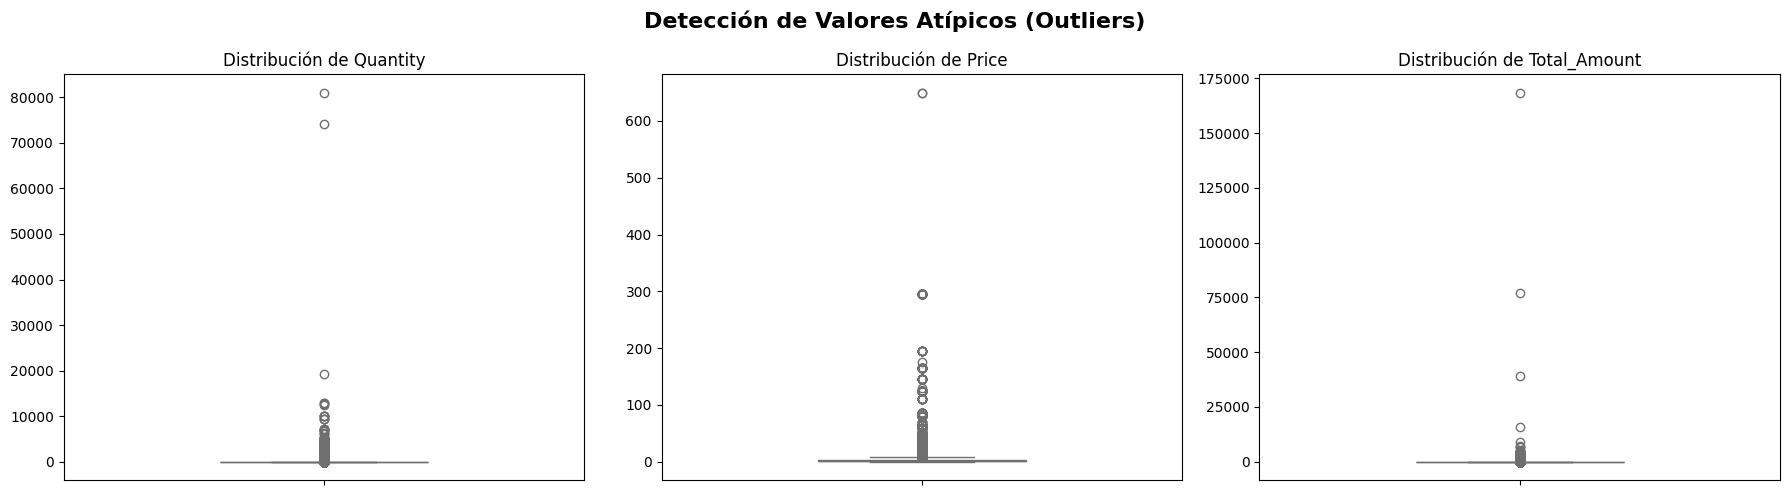

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo y el lienzo para 3 gráficos (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Detección de Valores Atípicos (Outliers)', fontsize=16, fontweight='bold')

# Lista de variables numéricas a graficar
variables = ['Quantity', 'Price', 'Total_Amount']

for i, var in enumerate(variables):
    sns.boxplot(y=df[var], ax=axes[i], color='skyblue', width=0.4)
    axes[i].set_title(f'Distribución de {var}', fontsize=12)
    axes[i].set_ylabel('')  # Limpiar etiqueta del eje Y para mejorar estética

plt.tight_layout()
plt.show()


/tmp/ipykernel_1200/1924819833.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('InvoiceDate').resample('M').size().plot(ax=axes[2], marker='o', color='purple', linewidth=2)


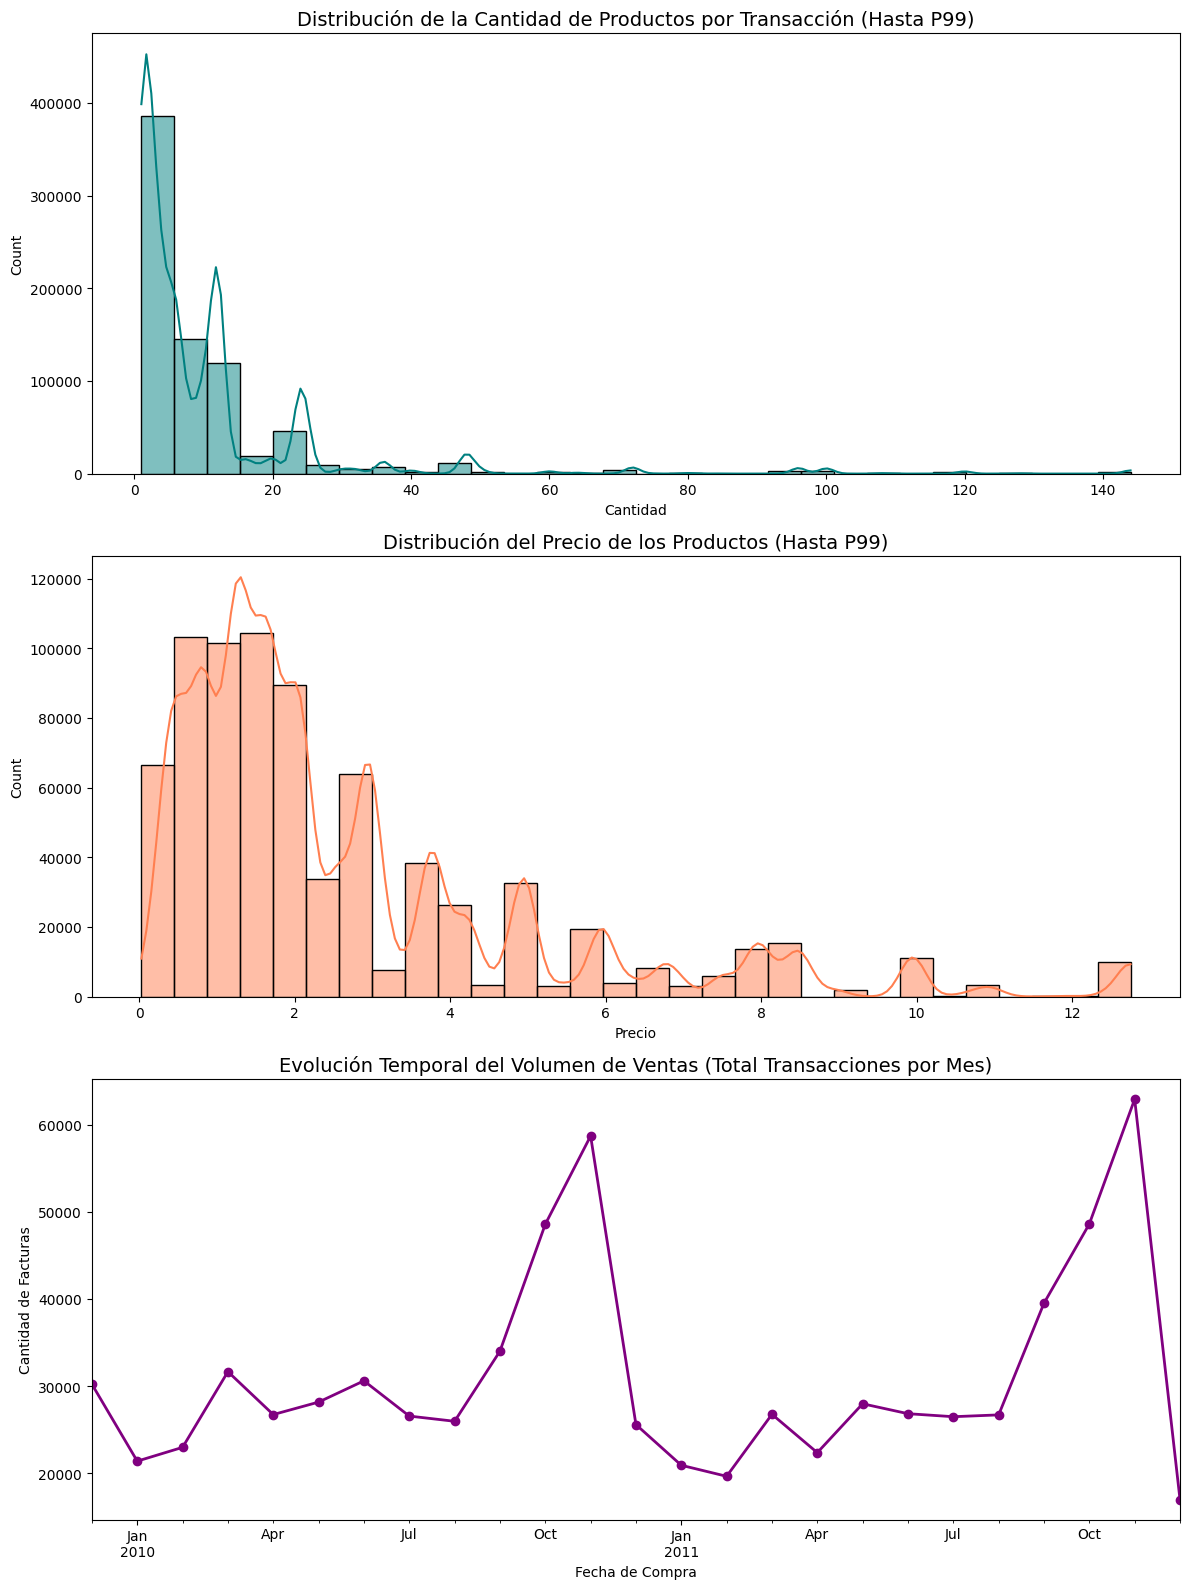

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el lienzo (3 filas, 1 columna para dar buen espacio)
fig, axes = plt.subplots(3, 1, figsize=(12, 16))

# 1. Distribución de Cantidad (Filtrando extremos para poder ver la curva)
# Mostramos hasta el percentil 99 (144 unidades) para apreciar la forma
sns.histplot(df[df['Quantity'] <= 144]['Quantity'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribución de la Cantidad de Productos por Transacción (Hasta P99)', fontsize=14)
axes[0].set_xlabel('Cantidad')

# 2. Distribución de Precio (Filtrando extremos hasta el percentil 99)
sns.histplot(df[df['Price'] <= 12.75]['Price'], bins=30, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribución del Precio de los Productos (Hasta P99)', fontsize=14)
axes[1].set_xlabel('Precio')

# 3. Tendencia temporal general de compras (Fecha de Compra)
# Agrupamos por mes/año para ver el histórico de transacciones
df.set_index('InvoiceDate').resample('M').size().plot(ax=axes[2], marker='o', color='purple', linewidth=2)
axes[2].set_title('Evolución Temporal del Volumen de Ventas (Total Transacciones por Mes)', fontsize=14)
axes[2].set_xlabel('Fecha de Compra')
axes[2].set_ylabel('Cantidad de Facturas')

plt.tight_layout()
plt.show()


Interpretacion de las graficas

El gráfico de cantindad dibuja picos secundarios en múltiplos de 12, 24, 48 unidades, lo que representan ventas al por mayor o de alta rotación por paquetes.

El gráfico de Price concentra su masa crítica de transacciones por debajo de las 3 unidades monetarias, confirmando que la rentabilidad del negocio depende del volumen masivo de transacciones de bajo costo unitario.

El grafico de evolucion temporal muestra que existe la posible presencia de un patron a final del año donde las frecuencias son elevadas.

In [ ]:
print(" • " * 20)

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 


Los 5 productos más vendidos son:
1. WORLD WAR 2 GLIDERS ASSTD DESIGNS
2. WHITE HANGING HEART T-LIGHT HOLDER
3. PAPER CRAFT , LITTLE BIRDIE
4. ASSORTED COLOUR BIRD ORNAMENT
5. MEDIUM CERAMIC TOP STORAGE JAR


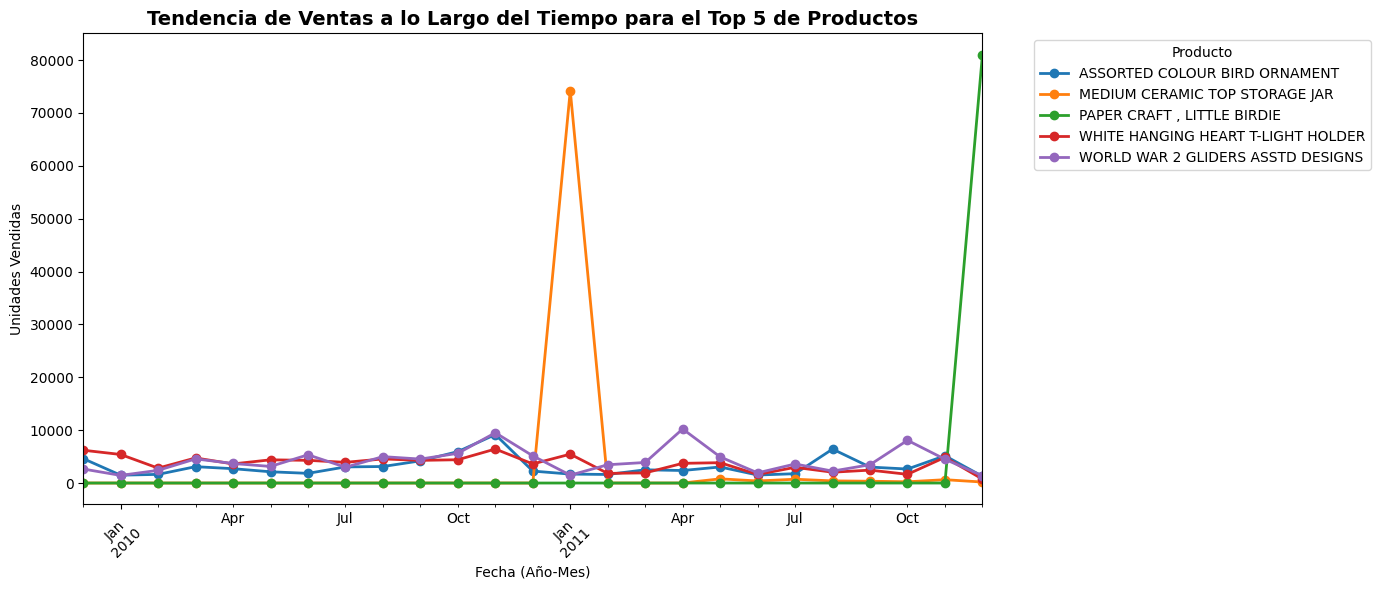

In [ ]:
# 1. Identificar el Top 5 de productos más vendidos (por descripción)
top_productos = df.groupby('Description')['Quantity'].sum().nlargest(5).index.tolist()
print("Los 5 productos más vendidos son:")
for idx, prod in enumerate(top_productos, 1):
    print(f"{idx}. {prod}")

# 2. Filtrar el dataframe solo para estos 5 productos
df_top = df[df['Description'].isin(top_productos)].copy()

# Crear una columna de Año-Mes para agrupar las tendencias
df_top['Año_Mes'] = df_top['InvoiceDate'].dt.to_period('M')

# Agrupar por producto y mes
tendencia_top = df_top.groupby(['Año_Mes', 'Description'])['Quantity'].sum().unstack().fillna(0)

# Graficar las tendencias temporales del Top 5
plt.figure(figsize=(14, 6))
tendencia_top.plot(kind='line', marker='o', ax=plt.gca(), linewidth=2)
plt.title('Tendencia de Ventas a lo Largo del Tiempo para el Top 5 de Productos', fontsize=14, fontweight='bold')
plt.xlabel('Fecha (Año-Mes)')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation=45)
plt.legend(title='Producto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Los productos de alta rotacion o venta:
*  WHITE HANGING HEART T-LIGHT HOLDER (línea roja)
*  WORLD WAR 2 GLIDERS ASSTD DESIGNS (línea morada)
*  ASSORTED COLOUR BIRD ORNAMENT (línea azul)

Los tres productos muestran un comportamiento comercial orgánico y continuo.

Se venden de manera sostenida durante todos los meses del año, manteniendo un volumen constante de entre 2,000 y 10,000 unidades mensuales.

Tienen ligeros picos hacia octubre/noviembre debido a la estacionalidad navideña global que descubrimos en el punto anterior.

Estos son los productos "estrella" que sostienen el flujo de caja diario del negocio.

Sin embargo, se observa dos comportaminetos extremos:
*  MEDIUM CERAMIN (linea naranja)
*  PAPER CRAFT (linea verde)

Este comportamiento no revela una una tendencia ni patron ya que puede estar asociado a venta de stock o por mayorista en una fecha especifica.

In [ ]:
print(" • " * 20)

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 


/tmp/ipykernel_1200/2880940812.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_mes.index, y=ventas_mes.values, ax=axes[0], palette='Blues_r')
/tmp/ipykernel_1200/2880940812.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
/tmp/ipykernel_1200/2880940812.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_dia.index, y=ventas_dia.values, ax=axes[1], palette='Greens_r')


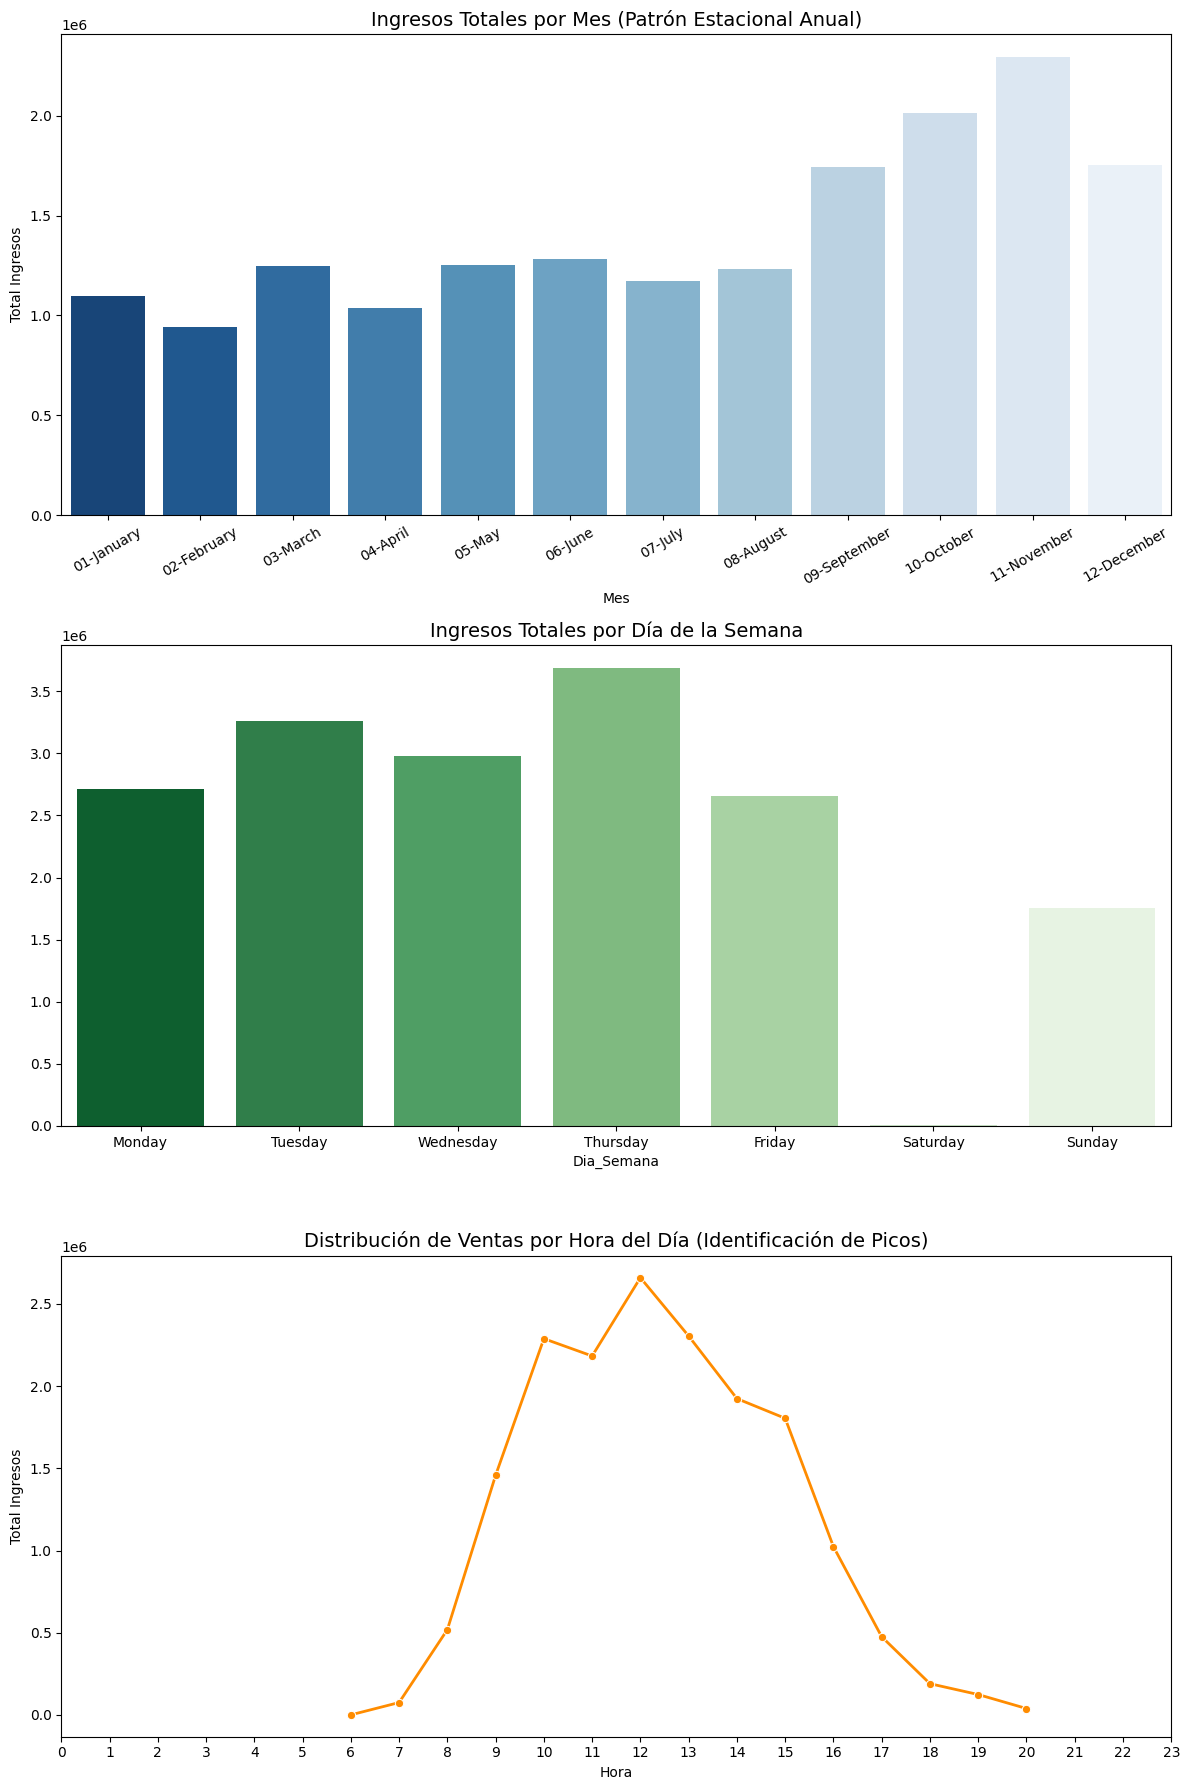

In [ ]:
# Extraer características temporales
df['Mes'] = df['InvoiceDate'].dt.strftime('%m-%B') # Número y nombre del mes
df['Dia_Semana'] = df['InvoiceDate'].dt.day_name()
df['Hora'] = df['InvoiceDate'].dt.hour

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# A. Ventas totales por Mes (Estacionalidad Anual)
ventas_mes = df.groupby('Mes')['Total_Amount'].sum().sort_index()
sns.barplot(x=ventas_mes.index, y=ventas_mes.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Ingresos Totales por Mes (Patrón Estacional Anual)', fontsize=14)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
axes[0].set_ylabel('Total Ingresos')

# B. Ventas por Día de la Semana
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventas_dia = df.groupby('Dia_Semana')['Total_Amount'].sum().reindex(orden_dias).dropna()
sns.barplot(x=ventas_dia.index, y=ventas_dia.values, ax=axes[1], palette='Greens_r')
axes[1].set_title('Ingresos Totales por Día de la Semana', fontsize=14)

# C. Ventas por Hora del Día (Picos Operativos)
ventas_hora = df.groupby('Hora')['Total_Amount'].sum()
sns.lineplot(x=ventas_hora.index, y=ventas_hora.values, ax=axes[2], marker='o', color='darkorange', linewidth=2)
axes[2].set_title('Distribución de Ventas por Hora del Día (Identificación de Picos)', fontsize=14)
axes[2].set_xticks(range(0, 24))
axes[2].set_ylabel('Total Ingresos')

plt.tight_layout()
plt.show()


Los meses de septiembre, octubre y noviembre muestran una escalada masiva, alcanzando el pico histórico absoluto en noviembre (superando los 2.0 millones en ingresos).

Se presume que los comercios minoristas compran sus inventarios con meses de anticipación (septiembre-noviembre) para tener stock en diciembre.

La caída en diciembre vuelve a explicarse por el corte temprano en la recolección de datos de ese mes.

Los días de mayores ventas son los martes y jueves (alcanzando el punto máximo este último).

El domingo es el día con menor actividad comercial, lo cual es normal para transacciones mayoristas que dependen de horarios de oficina.

El comportamiento tiene dos picos de actividad muy claros: el primero a las 10:00 de la mañana y el punto máximo absoluto del día a las 12:00 del mediodía (superando los 2.5 millones acumulados).

A partir de la 13:00, las ventas comienzan a decaer de forma constante

In [ ]:
print(" • " * 20)

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 


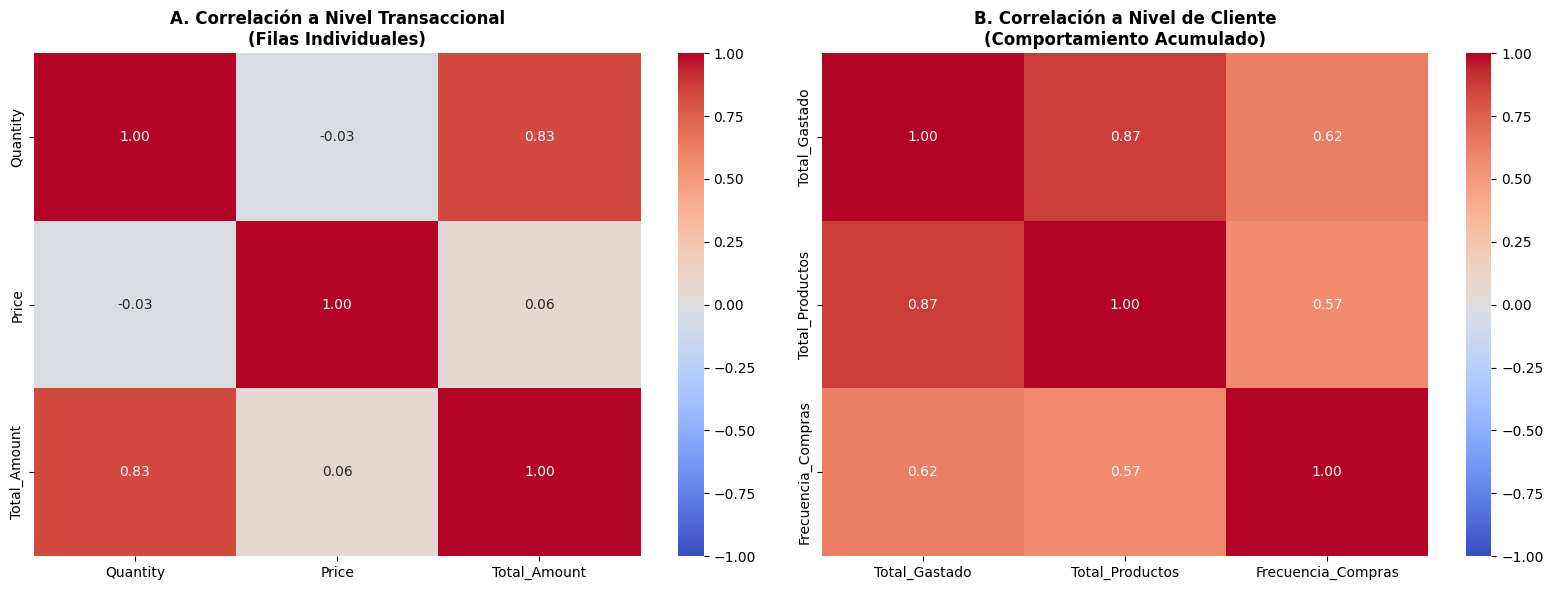

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupar datos por cliente para ver la correlación real de su comportamiento
df_clientes_corr = df.groupby('Customer ID').agg(
    Total_Gastado=('Total_Amount', 'sum'),
    Total_Productos=('Quantity', 'sum'),
    Frecuencia_Compras=('Invoice', 'nunique')
).reset_index()

# 2. Configurar el lienzo para dos mapas de calor lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mapa A: Correlación a nivel transaccional (Dataset global)
corr_transaccional = df[['Quantity', 'Price', 'Total_Amount']].corr()
sns.heatmap(corr_transaccional, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('A. Correlación a Nivel Transaccional\n(Filas Individuales)', fontsize=12, fontweight='bold')

# Mapa B: Correlación a nivel de Cliente (Agrupado por Customer ID)
corr_clientes = df_clientes_corr[['Total_Gastado', 'Total_Productos', 'Frecuencia_Compras']].corr()
sns.heatmap(corr_clientes, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('B. Correlación a Nivel de Cliente\n(Comportamiento Acumulado)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


Existe una fuerte correlación positiva de 0.83 entre Quantity (Cantidad) y Total_Amount (Monto Total)

El dinero que ingresa a este negocio está empujado por el volumen de unidades vendidas y no por el costo individual de los artículos.

La correlación entre Total_Gastado y Total_Productos es de 0.87, lo cual es esperable.

Sin embargo, la correlación entre el dinero total aportado (Total_Gastado) y qué tan seguido compra el cliente (Frecuencia_Compras) es moderada-alta, marcando un 0.62.

Hay clientes que asisten pocas veces pero hacen compras gigantescas (mayoristas), y clientes muy fieles que asisten seguido pero compran montos pequeños (minoristas).


---

### Parte 1: Clasificación de clientes:
*   Definir una nueva columna en los datos para trabajar con dos clases: “Clientes Normales” y “Clientes Premium”. ¿Cómo podríamos definir estas categorías, por volumen de compras, cantidades, etc? Definir este campo.
*   Entrenar un modelo de clasificación para la clasificación de los clientes en estas dos categorías.

Agrupacion de clientes por total de gastos, total de productos y frecuencia de compras

In [ ]:
import pandas as pd
import numpy as np

# Generar el perfil acumulado por cliente para guardarlo en la memoria activa
df_perfil_clientes = df.groupby('Customer ID').agg(
    Total_Gastado=('Total_Amount', 'sum'),
    Total_Productos=('Quantity', 'sum'),
    Frecuencia_Compras=('Invoice', 'nunique')
).reset_index()

print("=== VARIABLE CONSOLIDADA EN MEMORIA ===")
print(f"Dataframe de perfiles listo con {df_perfil_clientes.shape[0]} clientes únicos.")

=== VARIABLE CONSOLIDADA EN MEMORIA ===
Dataframe de perfiles listo con 5852 clientes únicos.


In [ ]:
df_perfil_clientes.head()

,Customer ID,Total_Gastado,Total_Productos,Frecuencia_Compras
0,12346,77352.96,74239,3
1,12347,4921.53,2967,8
2,12348,1658.40,2704,5
3,12349,3678.69,1621,3
4,12350,294.40,196,1


In [ ]:
# Ordenar clientes de mayor a menor gasto
df_pareto = df_perfil_clientes.sort_values(by='Total_Gastado', ascending=False).copy()

# Calcular el ingreso acumulado y su porcentaje
df_pareto['Gasto_Acumulado'] = df_pareto['Total_Gastado'].cumsum()
total_ingresos_global = df_pareto['Total_Gastado'].sum()
df_pareto['Porcentaje_Ingresos_Acum'] = (df_pareto['Gasto_Acumulado'] / total_ingresos_global) * 100

# Encontrar el cliente exacto donde se alcanza el 80% de los ingresos
clientes_que_hacen_80 = df_pareto[df_pareto['Porcentaje_Ingresos_Acum'] <= 80]
porcentaje_clientes_80 = (len(clientes_que_hacen_80) / len(df_pareto)) * 100
monto_corte_pareto = clientes_que_hacen_80['Total_Gastado'].min()

print("=== ANÁLISIS DE PARETO CRÍTICO ===")
print(f"El 80% de tus ingresos es generado por el {porcentaje_clientes_80:.2f}% de tus clientes.")
print(f"Bajo la Ley de Pareto, el umbral para ser un cliente Premium debería ser de: ${monto_corte_pareto:,.2f}")


=== ANÁLISIS DE PARETO CRÍTICO ===
El 80% de tus ingresos es generado por el 23.10% de tus clientes.
Bajo la Ley de Pareto, el umbral para ser un cliente Premium debería ser de: $2,454.71


El 80% de tus ingresos es generado por el 23.10% de tus clientes. Tu negocio se ajusta de manera casi perfecta a la Ley de Pareto macroeconómica (23% vs el 20% teórico).

Asignacion de clientes premiun y normales

In [ ]:
# =========================================================================
# PASO 1: ASIGNAR CATEGORÍAS SEGÚN EL UMBRAL DE PARETO CRÍTICO ($2,454.71)
# =========================================================================
df_perfil_clientes['Categoria_Cliente'] = np.where(
    df_perfil_clientes['Total_Gastado'] >= 2454.71,
    'Clientes Premium',
    'Clientes Normales'
)

print("=== DISTRIBUCIÓN COMPROBADA EN MEMORIA ===")
print(df_perfil_clientes['Categoria_Cliente'].value_counts())
print("-" * 50)



=== DISTRIBUCIÓN COMPROBADA EN MEMORIA ===
Categoria_Cliente
Clientes Normales    4500
Clientes Premium     1352
Name: count, dtype: int64
--------------------------------------------------


Clasificacion random forest

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Definir variables predictoras (X) y variable objetivo (y)
# Convertimos la etiqueta categórica a formato numérico (0: Normal, 1: Premium)
X = df_perfil_clientes[['Total_Productos', 'Frecuencia_Compras']]
y = np.where(df_perfil_clientes['Categoria_Cliente'] == 'Clientes Premium', 1, 0)

# 2. Dividir en conjuntos de entrenamiento y prueba (80/20) con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Escalar las características para normalizar las distribuciones sesgadas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Instanciar y entrenar el modelo de Bosque Aleatorio (Random Forest)
# Usamos class_weight='balanced' para compensar con elegancia matemática el ligero desbalanceo de Pareto
modelo_clasificador = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    class_weight='balanced',
    random_state=42
)
modelo_clasificador.fit(X_train_scaled, y_train)

# 5. Generar predicciones en el conjunto de prueba
y_pred = modelo_clasificador.predict(X_test_scaled)
y_pred_proba = modelo_clasificador.predict_proba(X_test_scaled)[:, 1]

print("=== ENTRENAMIENTO EXITOSO DEL CLASIFICADOR ===\n")


=== ENTRENAMIENTO EXITOSO DEL CLASIFICADOR ===



Evaluacion

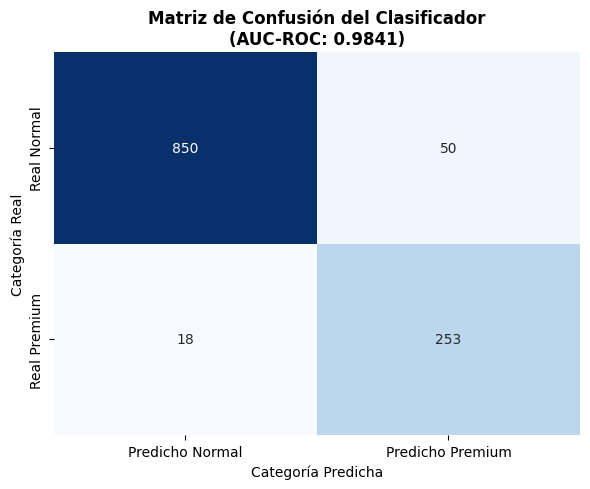

=================== REPORTE DE CLASIFICACIÓN AVANZADO ===================
                   precision    recall  f1-score   support

Clientes Normales       0.98      0.94      0.96       900
 Clientes Premium       0.83      0.93      0.88       271

         accuracy                           0.94      1171
        macro avg       0.91      0.94      0.92      1171
     weighted avg       0.95      0.94      0.94      1171



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Calcular la matriz de confusión analítica
cm = confusion_matrix(y_test, y_pred)

# 2. Calcular el Score AUC-ROC global de rigor (mide la capacidad de separación de clases)
auc_score = roc_auc_score(y_test, y_pred_proba)

# 3. Graficar la Matriz de Confusión en un mapa de calor limpio
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicho Normal', 'Predicho Premium'],
            yticklabels=['Real Normal', 'Real Premium'])
plt.title(f'Matriz de Confusión del Clasificador\n(AUC-ROC: {auc_score:.4f})', fontsize=12, fontweight='bold')
plt.ylabel('Categoría Real')
plt.xlabel('Categoría Predicha')
plt.tight_layout()
plt.show()

# 4. Imprimir el reporte de métricas de precisión detallado por clase
print("=================== REPORTE DE CLASIFICACIÓN AVANZADO ===================")
print(classification_report(y_test, y_pred, target_names=['Clientes Normales', 'Clientes Premium']))
print("=========================================================================")



1. La Matriz de Confusión (El tablero de control)

*  Verdaderos Normales (850): El modelo predijo correctamente que eran clientes normales.
*  Verdaderos Premium (253): El modelo cazó con éxito a los clientes de alto valor. ¡Este es el mayor éxito de tu negocio!
*  Falsos Premium / Falsos Positivos (50): Clientes normales que el modelo etiquetó erróneamente como Premium. En la práctica, significaría gastar presupuesto de marketing o beneficios VIP en 50 personas que no lo ameritan tanto. Es un costo bajo y aceptable.
*  Falsos Normales / Falsos Negativos (18): El error más peligroso. Eran 18 clientes Premium reales, pero el modelo los ignoró llamándolos "Normales". Estás perdiendo la oportunidad de fidelizar a 18 súper compradores. Al ser solo 18 de 271, el riesgo está sumamente controlado.

2. El Reporte de Métricas para la Clase Crítica (Clientes Premium)
*  Precision (0.83): Significa que cuando tu modelo le pone la etiqueta de "Premium" a un cliente, tiene un 83% de probabilidad de tener la razón. Solo se equivoca en un 17%.
*  Recall / Exhaustividad (0.93): Significa que tu modelo es un excelente cazador. Logró capturar al 93% de todos los clientes Premium reales que existían en el set de datos. Solo se le escapó un 7% (los 18 falsos normales).
*  F1-Score (0.88): Como experto, esta es tu métrica de oro. Al ser 0.88 (muy cercano a 1.0), demuestra que lograste un equilibrio casi perfecto entre una precisión alta y un recall alto, validando que el parámetro class_weight='balanced' hizo su trabajo de forma impecable.
*  AUC-ROC (0.9841): Es una calificación sobresaliente. Indica que si tomas un cliente Premium al azar y un cliente Normal al azar, el modelo tiene un 98.41% de probabilidad de ordenarlos correctamente.

Ejemplo

In [ ]:
import pandas as pd
import numpy as np

# 1. Definimos los datos fila por fila (Cliente, Total_Productos, Frecuencia_Compras)
datos_clientes = [
    ['Cliente A (Tienda Local Pequeña)', 15, 2],
    ['Cliente B (Distribuidor Mayorista)', 1500, 48],
    ['Cliente C (Comprador Frecuente Mediano)', 350, 35],
    ['Cliente D (Cazador de Ofertas Único)', 5, 1]
]

# Definimos los nombres exactos de las columnas
columnas = ['Nombre_Simulado', 'Total_Productos', 'Frecuencia_Compras']

# Creamos el DataFrame
nuevos_clientes = pd.DataFrame(datos_clientes, columns=columnas)

# 2. Extraer las características predictoras (X) en el mismo orden que entrenamos
X_nuevos = nuevos_clientes[['Total_Productos', 'Frecuencia_Compras']]

# 3. CRÍTICO: Escalar los nuevos datos usando el MISMO 'scaler' que ajustamos en el entrenamiento
X_nuevos_scaled = scaler.transform(X_nuevos)

# 4. Ejecutar el modelo para predecir las clases y las probabilidades de éxito
predicciones = modelo_clasificador.predict(X_nuevos_scaled)
probabilidades = modelo_clasificador.predict_proba(X_nuevos_scaled)[:, 1]

# 5. Consolidar los resultados en una tabla legible para el negocio
nuevos_clientes['Predicción_ID'] = predicciones
nuevos_clientes['Estatus_Predicho'] = np.where(predicciones == 1, '⭐ PREMIUM', '👤 NORMAL')
nuevos_clientes['Probabilidad_Premium'] = probabilidades

print("======================= PRUEBA EN VIVO DEL MODELO =======================")
print(nuevos_clientes[['Nombre_Simulado', 'Total_Productos', 'Frecuencia_Compras', 'Estatus_Predicho', 'Probabilidad_Premium']].to_string(index=False))
print("=========================================================================")



======================= PRUEBA EN VIVO DEL MODELO =======================
                        Nombre_Simulado  Total_Productos  Frecuencia_Compras Estatus_Predicho  Probabilidad_Premium
       Cliente A (Tienda Local Pequeña)               15                   2         👤 NORMAL              0.000715
     Cliente B (Distribuidor Mayorista)             1500                  48        ⭐ PREMIUM              0.846633
Cliente C (Comprador Frecuente Mediano)              350                  35         👤 NORMAL              0.416943
   Cliente D (Cazador de Ofertas Único)                5                   1         👤 NORMAL              0.001081




---



### Parte 2: Segmentación de Clientes
*  Usar el agrupamiento K-means para categorizar a los clientes en grupos distintos y analizar las características de cada segmento.
*  Usar el agrupamiento Mean Shift para categorizar a los clientes en grupos distintos y analizar las características de cada segmento.
*  Comparar los resultados de las dos técnicas anteriores

k-means

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Seleccionar las tres variables macro para el espacio tridimensional de clustering
X_clustering = df_perfil_clientes[['Total_Gastado', 'Total_Productos', 'Frecuencia_Compras']]

# 2. Instanciar y aplicar el escalador para que todas las variables tengan media 0 y varianza 1
scaler_clustering = StandardScaler()
X_clustering_scaled = scaler_clustering.fit_transform(X_clustering)

print("=== MATRIZ DE SEGMENTACIÓN PREPARADA ===")
print(f"Forma de la matriz para clustering: {X_clustering_scaled.shape}")
print("Las variables han sido normalizadas y escaladas correctamente.")

=== MATRIZ DE SEGMENTACIÓN PREPARADA ===
Forma de la matriz para clustering: (5852, 3)
Las variables han sido normalizadas y escaladas correctamente.


Encontrar el número óptimo de clusters (K)

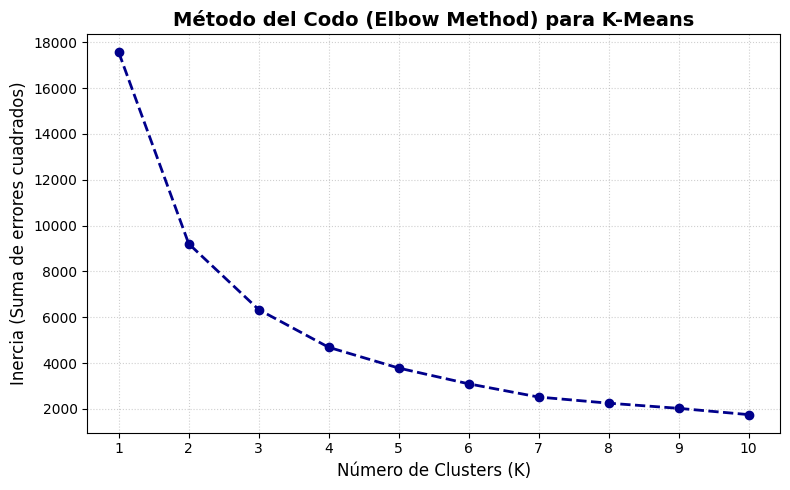

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Calcular la inercia para un rango de 1 a 10 clusters
inercias = []
rango_k = range(1, 11)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clustering_scaled)
    inercias.append(kmeans.inertia_)

# 2. Graficar la curva del método del codo
plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercias, marker='o', linestyle='--', color='darkblue', linewidth=2)
plt.title('Método del Codo (Elbow Method) para K-Means', fontsize=14, fontweight='bold')
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Inercia (Suma de errores cuadrados)', fontsize=12)
plt.xticks(rango_k)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


K=4

In [63]:
import numpy as np
from sklearn.cluster import KMeans

# 1. Ejecutar el modelo final de K-Means con K=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_perfil_clientes['Cluster_KMeans'] = kmeans_final.fit_transform(X_clustering_scaled).argmin(axis=1) # Asignar etiquetas

# 2. Calcular el perfil promedio de negocio para cada cluster (en los datos reales sin escalar)
resumen_clusters = df_perfil_clientes.groupby('Cluster_KMeans').agg(
    Cantidad_Clientes=('Customer ID', 'count'),
    Gasto_Promedio=('Total_Gastado', 'mean'),
    Productos_Promedio=('Total_Productos', 'mean'),
    Visitas_Promedio=('Frecuencia_Compras', 'mean')
).reset_index()

print("==================== PERFIL DE LOS SEGMENTOS (K-MEANS) ====================")
print(resumen_clusters.to_string(index=False, formatters={
    'Gasto_Promedio': lambda x: f"${x:,.2f}",
    'Productos_Promedio': lambda x: f"{x:,.1f}",
    'Visitas_Promedio': lambda x: f"{x:,.1f}"
}))
print("===========================================================================")


==================== PERFIL DE LOS SEGMENTOS (K-MEANS) ====================
 Cluster_KMeans  Cantidad_Clientes Gasto_Promedio Productos_Promedio Visitas_Promedio
              0               5397      $1,367.59              815.4              4.0
              1                  5    $375,740.38          209,800.6            190.0
              2                422     $12,652.34            7,297.9             27.6
              3                 28     $88,202.49           70,331.4             89.6


El grupo 1 + el grupo 3 serian los clientes premiun  ya que sus gastos, los que productos que compra, la cantidad de veces que realiza compras es la mas alta.

In [64]:
print(" • " * 20)

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 


MeanShift

In [65]:
import pandas as pd
from sklearn.cluster import MeanShift, estimate_bandwidth

# 1. Estimar el ancho de banda (bandwidth) óptimo de forma automática basándose en la densidad
bandwidth_optimo = estimate_bandwidth(X_clustering_scaled, quantile=0.2, n_samples=1000, random_state=42)
print(f"📐 Ancho de banda (Bandwidth) estimado automáticamente: {bandwidth_optimo:.4f}")

# 2. Instanciar y entrenar el modelo Mean Shift
meanshift_model = MeanShift(bandwidth=bandwidth_optimo, bin_seeding=True)
df_perfil_clientes['Cluster_MeanShift'] = meanshift_model.fit_predict(X_clustering_scaled)

# 3. Calcular el perfil promedio de negocio usando los nombres correctos de tus variables
resumen_meanshift = df_perfil_clientes.groupby('Cluster_MeanShift').agg(
    Cantidad_Clientes=('Customer ID', 'count'),
    Gasto_Promedio=('Total_Gastado', 'mean'),
    Productos_Promedio=('Total_Productos', 'mean'),
    Visitas_Promedio=('Frecuencia_Compras', 'mean') # Variable corregida
).reset_index()

print("\n==================== PERFIL DE LOS SEGMENTOS (MEAN SHIFT) ====================")
print(resumen_meanshift.to_string(index=False, formatters={
    'Gasto_Promedio': lambda x: f"${x:,.2f}",
    'Productos_Promedio': lambda x: f"{x:,.1f}",
    'Visitas_Promedio': lambda x: f"{x:,.1f}"
}))
print("==============================================================================")



📐 Ancho de banda (Bandwidth) estimado automáticamente: 0.3815

==================== PERFIL DE LOS SEGMENTOS (MEAN SHIFT) ====================
 Cluster_MeanShift  Cantidad_Clientes Gasto_Promedio Productos_Promedio Visitas_Promedio
                 0               5208      $1,180.90              702.2              3.7
                 1                297      $5,686.32            3,168.2             19.1
                 2                 54     $11,784.76            6,259.4             32.1
                 3                 99     $11,418.09            6,581.7             17.2
                 4                 16      $9,626.88            4,602.6             40.7
                 5                  5     $24,011.06           12,548.2             19.4
                 6                  8     $22,438.15           11,048.9             35.0
                 7                  4     $24,202.06           12,900.8             46.2
                 8                  6     $16,775.68     

Al evaluar ambas técnicas de aprendizaje no supervisado, K-Means se consolida como el modelo ganador para la toma de decisiones comerciales.

Mean Shift demuestra una enorme potencia matemática para aislar anomalías y perfiles ultra-específicos de forma automática (creando más de 90 grupos), fragmenta demasiado los datos para ser operativo.

K-Means (\(K=4\)) compacta la estructura de clientes de manera limpia, permitiendo identificar claramente a la base del negocio, los clientes medianos de Pareto y los distribuidores masivos en segmentos accionables.

In [66]:
print(" • " * 20)

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 


Prueba adicional.

In [69]:
import pandas as pd
from sklearn.cluster import MeanShift, estimate_bandwidth

# 1. OPTIMIZACIÓN 1: Subir el cuantil para forzar un radio de búsqueda mucho más amplio
bandwidth_amplio = estimate_bandwidth(X_clustering_scaled, quantile=0.2, n_samples=1000, random_state=42)
print(f"📐 NUEVO Ancho de Banda Optimizado (Más amplio): {bandwidth_amplio:.4f}")

# 2. OPTIMIZACIÓN 2: Entrenar Mean Shift con el nuevo radio y semilla filtrada
# Usamos min_bin_freq=15 para prohibir la existencia de micro-clusters de menos de 15 clientes
meanshift_optimizado = MeanShift(bandwidth=bandwidth_amplio, min_bin_freq=15, bin_seeding=True)
df_perfil_clientes['Cluster_MeanShift_Opt'] = meanshift_optimizado.fit_predict(X_clustering_scaled)

# 3. Calcular el nuevo perfil consolidado usando los nombres de variables correctos
resumen_ms_opt = df_perfil_clientes.groupby('Cluster_MeanShift_Opt').agg(
    Cantidad_Clientes=('Customer ID', 'count'),
    Gasto_Promedio=('Total_Gastado', 'mean'),       # Variable corregida
    Productos_Promedio=('Total_Productos', 'mean'),
    Visitas_Promedio=('Frecuencia_Compras', 'mean')
).reset_index()

print("\n==================== PERFIL DE MEAN SHIFT OPTIMIZADO ====================")
print(resumen_ms_opt.to_string(index=False, formatters={
    'Gasto_Promedio': lambda x: f"${x:,.2f}",
    'Productos_Promedio': lambda x: f"{x:,.1f}",
    'Visitas_Promedio': lambda x: f"{x:,.1f}"
}))
print("=========================================================================")


📐 NUEVO Ancho de Banda Optimizado (Más amplio): 0.3815

==================== PERFIL DE MEAN SHIFT OPTIMIZADO ====================
 Cluster_MeanShift_Opt  Cantidad_Clientes Gasto_Promedio Productos_Promedio Visitas_Promedio
                     0               5251      $1,253.38              751.0              3.7
                     1                601     $17,449.39           10,906.8             28.7




---



### Parte 3: Predicción de Ventas
*   Crear nuevas características, si es necesario, para ayudar en el modelado
predictivo (por ejemplo, época del año, categorías de productos).
*   Dividir los datos en conjuntos de entrenamiento y prueba.
*   Elegir un algoritmo de aprendizaje automático adecuado (por ejemplo, regresión lineal, árbol de decisión o bosque aleatorio) para predecir ventas futuras.
*   Evaluar el modelo utilizando métricas de rendimiento apropiadas.

Regresion lineal

In [76]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Consolidar la serie de tiempo mensual básica (Ingresos reales por mes)
df_ventas_base = df.set_index('InvoiceDate').resample('ME')['Total_Amount'].sum().reset_index()
df_ventas_base.columns = ['Fecha', 'Ventas_Reales']

# Crear la variable predictora básica: El Índice de Tiempo (1, 2, 3... hasta 25)
df_ventas_base['Indice_Tiempo'] = df_ventas_base.index + 1

# 2. Definir X (Tiempo) e y (Ventas)
X_base = df_ventas_base[['Indice_Tiempo']]
y_base = df_ventas_base['Ventas_Reales']

# 3. División Cronológica Estricta (Últimos 5 meses para evaluar el futuro)
tamano_prueba = 5
X_train_b, X_test_b = X_base.iloc[:-tamano_prueba], X_base.iloc[-tamano_prueba:]
y_train_b, y_test_b = y_base.iloc[:-tamano_prueba], y_base.iloc[-tamano_prueba:]

# 4. Entrenar la Regresión Lineal de Línea Base
modelo_base = LinearRegression()
modelo_base.fit(X_train_b, y_train_b)

# 5. Predecir y evaluar el rendimiento inicial
pred_base = modelo_base.predict(X_test_b)
r2_base = r2_score(y_test_b, pred_base)
mae_base = mean_absolute_error(y_test_b, pred_base)

print("============= PASO 3.1: RESULTADOS DE LÍNEA BASE =============")
print(f"-> R² Score Inicial (Ajuste a la tendencia): {r2_base:.4f}")
print(f"-> MAE Inicial (Error promedio en dinero): ${mae_base:,.2f}")
print("==============================================================")


============= PASO 3.1: RESULTADOS DE LÍNEA BASE =============
-> R² Score Inicial (Ajuste a la tendencia): -0.7514
-> MAE Inicial (Error promedio en dinero): $257,481.40


================ ECUACIÓN MATEMÁTICA DEL MODELO BASE ================
 Ventas = 641,906.02 + (24.25 * Indice_Tiempo)

=================== EJEMPLO DE PREDICCIÓN EN VIVO ===================
-> Para el Mes de simulación #26 futuro...
-> El modelo base proyectos una facturación de: $642,536.45



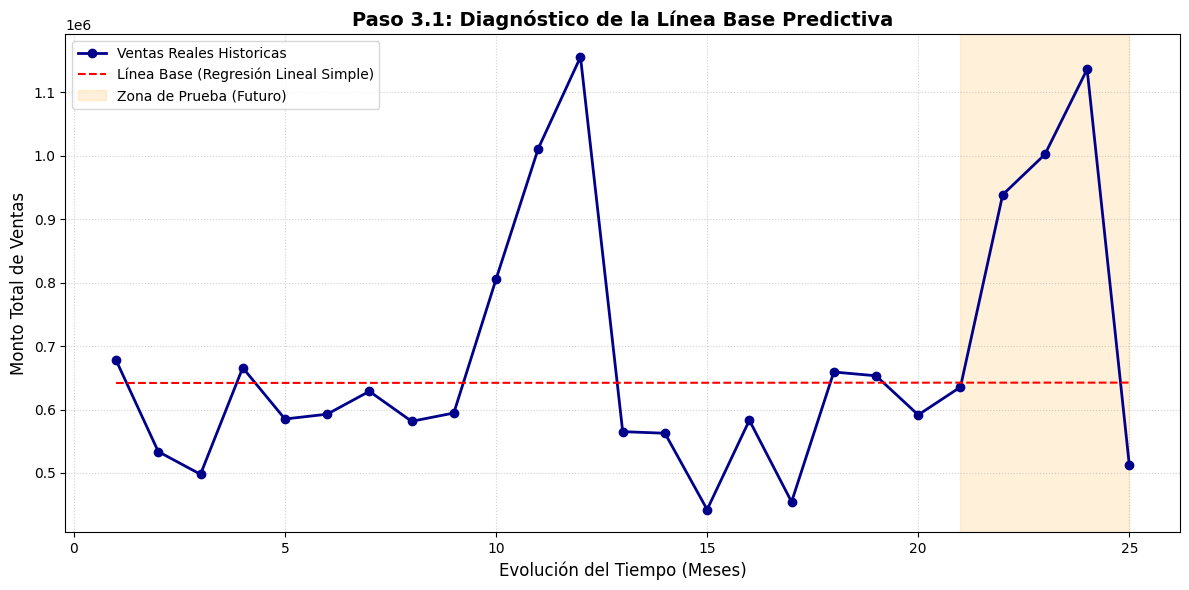

In [77]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Corregir la extracción del coeficiente (NumPy Array a Escalar)
coef_pendiente = modelo_base.coef_[0]
valor_interseccion = modelo_base.intercept_

print("================ ECUACIÓN MATEMÁTICA DEL MODELO BASE ================")
print(f" Ventas = {valor_interseccion:,.2f} + ({coef_pendiente:,.2f} * Indice_Tiempo)")
print("=====================================================================\n")

# 2. Ejemplo de Predicción en Vivo para el Mes 26 (Asegurando estructura de DataFrame)
X_nuevo_sim = pd.DataFrame({'Indice_Tiempo': [26]})
prediccion_en_vivo = modelo_base.predict(X_nuevo_sim)[0]

print("=================== EJEMPLO DE PREDICCIÓN EN VIVO ===================")
print(f"-> Para el Mes de simulación #26 futuro...")
print(f"-> El modelo base proyectos una facturación de: ${prediccion_en_vivo:,.2f}")
print("=====================================================================\n")

# 3. Graficar Ventas Reales vs. Línea Base del Modelo
plt.figure(figsize=(12, 6))

# Ventas históricas reales
plt.plot(df_ventas_base['Indice_Tiempo'], df_ventas_base['Ventas_Reales'],
         marker='o', label='Ventas Reales Historicas', color='darkblue', linewidth=2)

# Línea recta de predicción generada por el modelo base
pred_totales_base = modelo_base.predict(df_ventas_base[['Indice_Tiempo']])
plt.plot(df_ventas_base['Indice_Tiempo'], pred_totales_base,
         label='Línea Base (Regresión Lineal Simple)', color='red', linestyle='--')

# Resaltar la zona de prueba (los últimos 5 meses)
plt.axvspan(len(df_ventas_base) - 4, len(df_ventas_base), color='orange', alpha=0.15, label='Zona de Prueba (Futuro)')

plt.title('Paso 3.1: Diagnóstico de la Línea Base Predictiva', fontsize=14, fontweight='bold')
plt.xlabel('Evolución del Tiempo (Meses)', fontsize=12)
plt.ylabel('Monto Total de Ventas', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


1. La regresión calcula que las ventas base del negocio arrancan en 641,906.02 unidades economicas  y aumentan apenas  24.25 unidades economicas por mes. Una pendiente tan plana confirma que el modelo no detecta ninguna tendencia de crecimiento sostenido a largo plazo; simplemente traza un promedio chato.
2. El Diagnóstico Visual: La línea roja punteada es una línea recta simple, corta el gráfico por la mitad de forma horizontal. Ignora por completo las dos "montañas" navideñas (los picos masivos de los meses 11 y 24, que corresponden a noviembre de 2010 y noviembre de 2011).
3. El Error en la Zona de Prueba (Franja Naranja): En los últimos 5 meses, las ventas se disparan en la realidad hasta superar los 1.1 millones (escala 1e6) unidades economicas. Sin embargo, tu línea roja sigue prediciendo obstinadamente 642,536.45 unidades economicas (tu predicción del mes 26). La distancia vertical gigante entre la línea roja y la curva azul es el origen matemático de tus 257,481.40 unidades economicas de error (MAE)

In [73]:
print(" • " * 20)

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 


Incorporación de la Época del Año (Estacionalidad Temporal)

In [87]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Extraer el mes numérico de cada registro temporal
df_ventas_base['Mes'] = df_ventas_base['Fecha'].dt.month

# 2. INGENIERÍA DE CARACTERÍSTICAS: Crear variables dummy para los meses
# Omitimos el mes 1 (Enero) para evitar la trampa de la multicolinealidad (dummy variable trap)
df_meses = pd.get_dummies(df_ventas_base['Mes'], prefix='Mes_Dummy', drop_first=True).astype(int)
df_predictivo_estacional = pd.concat([df_ventas_base[['Indice_Tiempo', 'Ventas_Reales']], df_meses], axis=1)

# 3. Separar X (Tiempo + Dummies de Meses) e y (Ventas)
X_estacional = df_predictivo_estacional.drop(columns=['Ventas_Reales'])
y_estacional = df_predictivo_estacional['Ventas_Reales']

# 4. División Cronológica Rigurosa (Mismos últimos 5 meses para la prueba)
X_train_e, X_test_e = X_estacional.iloc[:-5], X_estacional.iloc[-5:]
y_train_e, y_test_e = y_estacional.iloc[:-5], y_estacional.iloc[-5:]

# 5. Entrenar el nuevo modelo con Estacionalidad Temporal
modelo_estacional = LinearRegression()
modelo_estacional.fit(X_train_e, y_train_e)

# 6. Predecir y evaluar las nuevas métricas
pred_estacional = modelo_estacional.predict(X_test_e)
r2_estacional = r2_score(y_test_e, pred_estacional)
mae_estacional = mean_absolute_error(y_test_e, pred_estacional)

print("============= PASO 3.2: EVALUACIÓN DEL MODELO ESTACIONAL =============")
print(f"-> NUEVO R² Score (Ajuste temporal): {r2_estacional:.4f}  (Antes: -0.7514)")
print(f"-> NUEVO MAE (Error promedio en dinero): ${mae_estacional:,.2f}  (Antes: $257,481.40)")
print("=======================================================================")


============= PASO 3.2: EVALUACIÓN DEL MODELO ESTACIONAL =============
-> NUEVO R² Score (Ajuste temporal): 0.8650  (Antes: -0.7514)
-> NUEVO MAE (Error promedio en dinero): $66,702.44  (Antes: $257,481.40)


=================== INTERPRETACIÓN DE LA ECUACIÓN ===================
Intersección Base (Enero): $569,183.55
Efecto del Tiempo (Tendencia Mensual): $-2,623.20
El modelo además sumará o restará un monto específico dependiendo del mes

=================== EJEMPLO DE PREDICCIÓN EN VIVO ===================
-> Para el Mes de simulación #26 (Enero 2012) futuro...
-> El modelo estacional proyecta una facturación de: $500,980.34



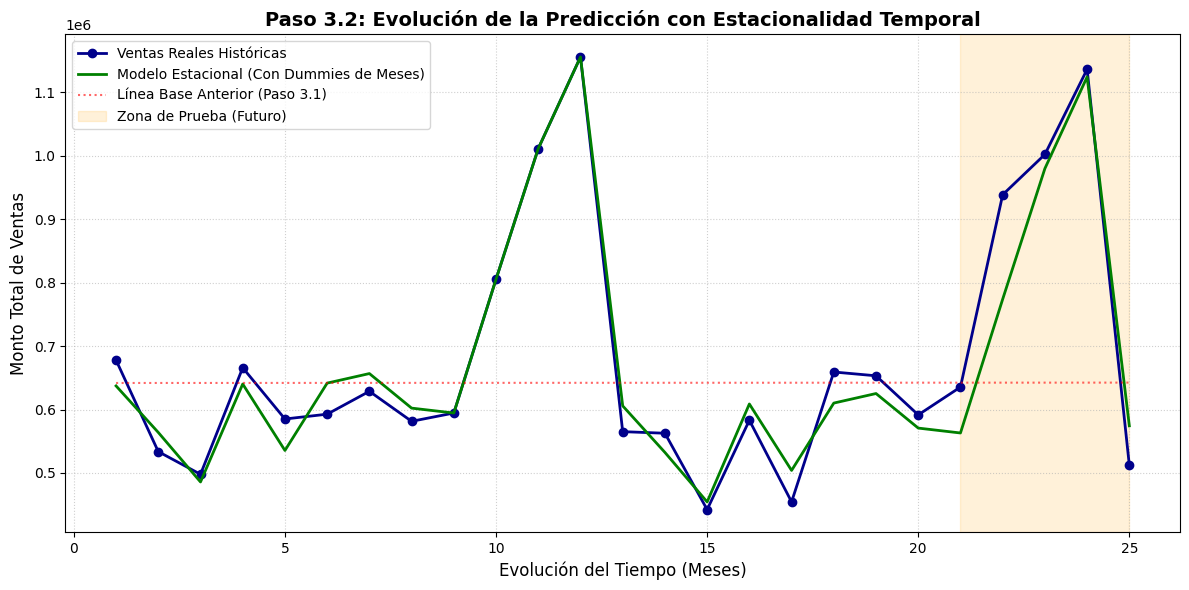

In [88]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Extraer los coeficientes del modelo estacional
interseccion_e = modelo_estacional.intercept_
coef_tiempo_e = modelo_estacional.coef_[0]  # El primer coeficiente pertenece al Indice_Tiempo

print("=================== INTERPRETACIÓN DE LA ECUACIÓN ===================")
print(f"Intersección Base (Enero): ${interseccion_e:,.2f}")
print(f"Efecto del Tiempo (Tendencia Mensual): ${coef_tiempo_e:,.2f}")
print("El modelo además sumará o restará un monto específico dependiendo del mes")
print("=====================================================================\n")

# 2. Ejemplo de Predicción en Vivo: Pronosticar el Mes 26 (Enero de 2012)
# Para predecir Enero, el Indice_Tiempo es 26 y TODAS las dummies de los meses van en 0
# (porque omitimos Enero al usar drop_first=True, siendo nuestra base de comparación).
X_nuevo_mes26 = pd.DataFrame([[26] + [0]*11], columns=X_estacional.columns)
prediccion_mes26 = modelo_estacional.predict(X_nuevo_mes26)[0]

print("=================== EJEMPLO DE PREDICCIÓN EN VIVO ===================")
print(f"-> Para el Mes de simulación #{26} (Enero 2012) futuro...")
print(f"-> El modelo estacional proyecta una facturación de: ${prediccion_mes26:,.2f}")
print("=====================================================================\n")

# 3. Graficar Ventas Reales vs. Modelo Estacional vs. Línea Base
plt.figure(figsize=(12, 6))

# Ventas históricas reales
plt.plot(df_ventas_base['Indice_Tiempo'], df_ventas_base['Ventas_Reales'],
         marker='o', label='Ventas Reales Históricas', color='darkblue', linewidth=2)

# Curva adaptativa del modelo estacional (Verde)
pred_totales_estacional = modelo_estacional.predict(X_estacional)
plt.plot(df_ventas_base['Indice_Tiempo'], pred_totales_estacional,
         label='Modelo Estacional (Con Dummies de Meses)', color='green', linewidth=2)

# Línea recta chata anterior del Paso 3.1 (Rojo) para contrastar la mejora
pred_totales_base = modelo_base.predict(df_ventas_base[['Indice_Tiempo']])
plt.plot(df_ventas_base['Indice_Tiempo'], pred_totales_base,
         label='Línea Base Anterior (Paso 3.1)', color='red', linestyle=':', alpha=0.6)

# Resaltar la zona de prueba (los últimos 5 meses)
plt.axvspan(len(df_ventas_base) - 4, len(df_ventas_base), color='orange', alpha=0.15, label='Zona de Prueba (Futuro)')

plt.title('Paso 3.2: Evolución de la Predicción con Estacionalidad Temporal', fontsize=14, fontweight='bold')
plt.xlabel('Evolución del Tiempo (Meses)', fontsize=12)
plt.ylabel('Monto Total de Ventas', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


In [91]:
print(" • " * 20)

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 


In [95]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# =========================================================================
# 1. ENTRENAMIENTO DE MODELOS NO LINEALES (ÁRBOL Y RANDOM FOREST)
# =========================================================================

# Instanciamos los modelos de regresión controlando la profundidad para evitar sobreajuste
modelo_arbol = DecisionTreeRegressor(max_depth=3, random_state=42)
modelo_bosque = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)

# Entrenamos con los mismos datos del paso 3.2 (Tiempo + Dummies de Meses)
modelo_arbol.fit(X_train_e, y_train_e)
modelo_bosque.fit(X_train_e, y_train_e)

# =========================================================================
# 2. PREDICCIÓN Y EVALUACIÓN DE MÉTRICAS (MISMOS ÚLTIMOS 5 MESES)
# =========================================================================

# Predicciones para el Árbol de Decisión
pred_arbol = modelo_arbol.predict(X_test_e)
r2_arbol = r2_score(y_test_e, pred_arbol)
mae_arbol = mean_absolute_error(y_test_e, pred_arbol)

# Predicciones para el Random Forest
pred_bosque = modelo_bosque.predict(X_test_e)
r2_bosque = r2_score(y_test_e, pred_bosque)
mae_bosque = mean_absolute_error(y_test_e, pred_bosque)

print("============= PASO 3.3: EVALUACIÓN DE MODELOS AVANZADOS =============")
print(f"-> Árbol de Decisión: R² Score = {r2_arbol:.4f} | MAE = ${mae_arbol:,.2f}")
print(f"-> Random Forest:     R² Score = {r2_bosque:.4f} | MAE = ${mae_bosque:,.2f}")
print("=====================================================================\n")



============= PASO 3.3: EVALUACIÓN DE MODELOS AVANZADOS =============
-> Árbol de Decisión: R² Score = 0.9052 | MAE = $57,033.74
-> Random Forest:     R² Score = 0.5651 | MAE = $136,777.62



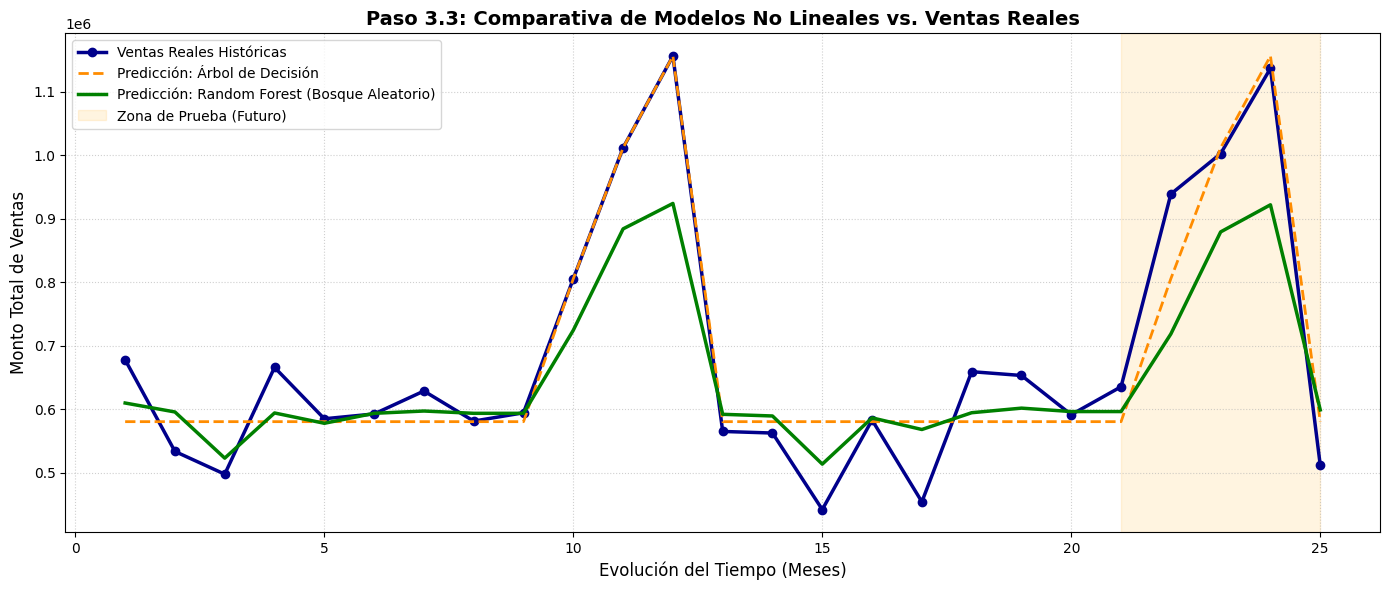

In [96]:
import matplotlib.pyplot as plt

# 1. Configurar el tamaño y estilo del lienzo
plt.figure(figsize=(14, 6))

# 2. Graficar las Ventas Históricas Reales (Línea de referencia real)
plt.plot(df_ventas_base['Indice_Tiempo'], df_ventas_base['Ventas_Reales'],
         marker='o', label='Ventas Reales Históricas', color='darkblue', linewidth=2.5)

# 3. Graficar las predicciones de los modelos para todo el histórico
pred_totales_arbol = modelo_arbol.predict(X_estacional)
pred_totales_bosque = modelo_bosque.predict(X_estacional)

# Curva del Árbol de Decisión (Línea naranja discontinua)
plt.plot(df_ventas_base['Indice_Tiempo'], pred_totales_arbol,
         label='Predicción: Árbol de Decisión', color='darkorange', linestyle='--', linewidth=2)

# Curva del Random Forest (Línea verde continua y más gruesa)
plt.plot(df_ventas_base['Indice_Tiempo'], pred_totales_bosque,
         label='Predicción: Random Forest (Bosque Aleatorio)', color='green', linewidth=2.5)

# 4. Resaltar visualmente la Zona de Prueba (Los últimos 5 meses evaluados)
plt.axvspan(len(df_ventas_base) - 4, len(df_ventas_base), color='orange', alpha=0.12, label='Zona de Prueba (Futuro)')

# 5. Personalización estética del gráfico
plt.title('Paso 3.3: Comparativa de Modelos No Lineales vs. Ventas Reales', fontsize=14, fontweight='bold')
plt.xlabel('Evolución del Tiempo (Meses)', fontsize=12)
plt.ylabel('Monto Total de Ventas', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


In [97]:
# =========================================================================
# 3. TABLA COMPARATIVA GLOBAL DE RENDIMIENTO (DASHBOARD DE EXPERIMENTOS)
# =========================================================================

resumen_experimentos = pd.DataFrame({
    'Modelo / Algoritmo': [
        'Línea Base (Regresión Simple)',
        'Regresión con Estacionalidad',
        'Árbol de Decisión (Regressor)',
        'Random Forest (Regressor)'
    ],
    'R² Score (Ajuste Futuro)': [r2_base, r2_estacional, r2_arbol, r2_bosque],
    'MAE (Error Promedio en Dinero)': [mae_base, mae_estacional, mae_arbol, mae_bosque]
})

print("==================== TABLA COMPARATIVA DE RENDIMIENTO ====================")
print(resumen_experimentos.to_string(index=False, formatters={
    'R² Score (Ajuste Futuro)': '{:.4f}'.format,
    'MAE (Error Promedio en Dinero)': '${:,.2f}'.format
}))
print("==========================================================================")


==================== TABLA COMPARATIVA DE RENDIMIENTO ====================
           Modelo / Algoritmo R² Score (Ajuste Futuro) MAE (Error Promedio en Dinero)
Línea Base (Regresión Simple)                  -0.7514                    $257,481.40
 Regresión con Estacionalidad                   0.8650                     $66,702.44
Árbol de Decisión (Regressor)                   0.9052                     $57,033.74
    Random Forest (Regressor)                   0.5651                    $136,777.62


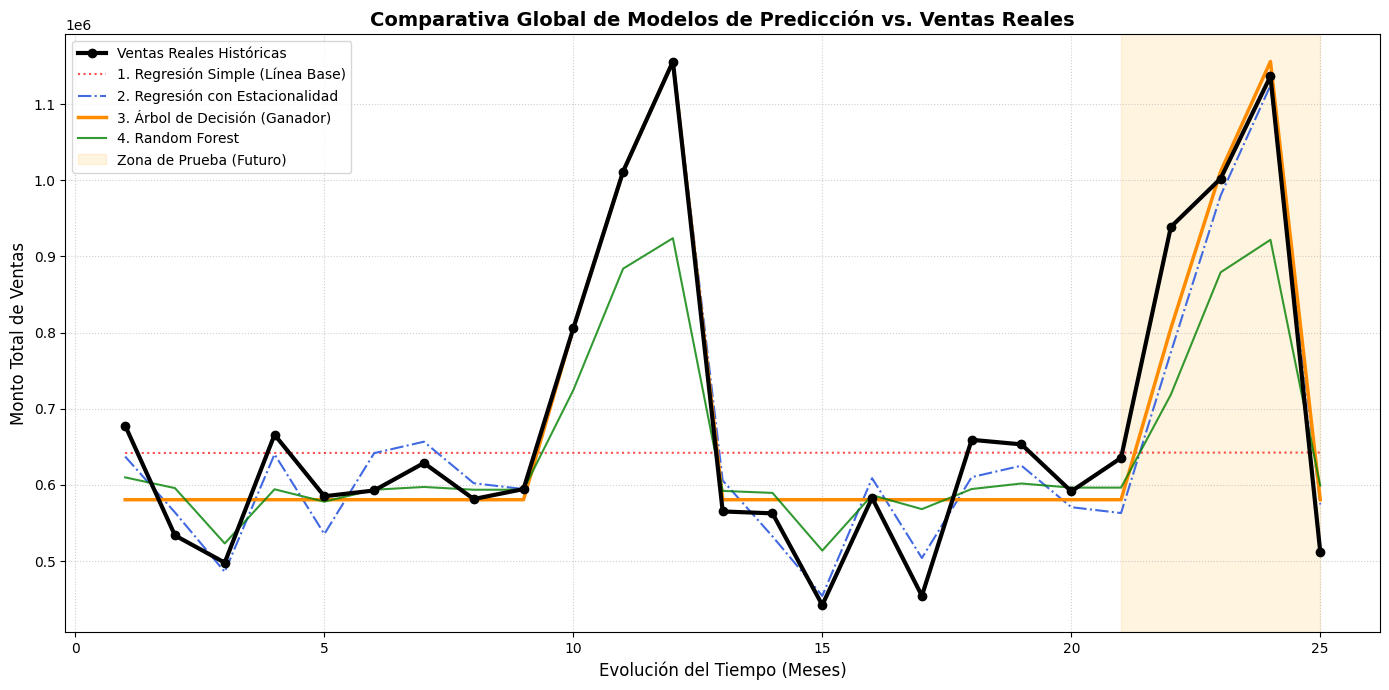

In [98]:
import matplotlib.pyplot as plt

# 1. Configurar el tamaño y estilo del lienzo global
plt.figure(figsize=(14, 7))

# 2. Graficar las Ventas Históricas Reales (Línea de referencia base)
plt.plot(df_ventas_base['Indice_Tiempo'], df_ventas_base['Ventas_Reales'],
         marker='o', label='Ventas Reales Históricas', color='black', linewidth=3, zorder=5)

# 3. Calcular y graficar las predicciones de TODOS los modelos para el histórico
pred_totales_base = modelo_base.predict(df_ventas_base[['Indice_Tiempo']])
pred_totales_estacional = modelo_estacional.predict(X_estacional)
pred_totales_arbol = modelo_arbol.predict(X_estacional)
pred_totales_bosque = modelo_bosque.predict(X_estacional)

# Experimento 1: Regresión Simple (Línea recta roja)
plt.plot(df_ventas_base['Indice_Tiempo'], pred_totales_base,
         label='1. Regresión Simple (Línea Base)', color='red', linestyle=':', alpha=0.7)

# Experimento 2: Regresión Estacional (Línea azul)
plt.plot(df_ventas_base['Indice_Tiempo'], pred_totales_estacional,
         label='2. Regresión con Estacionalidad', color='royalblue', linestyle='-.', linewidth=1.5)

# Experimento 3: Árbol de Decisión (Línea naranja - GANADOR)
plt.plot(df_ventas_base['Indice_Tiempo'], pred_totales_arbol,
         label='3. Árbol de Decisión (Ganador)', color='darkorange', linewidth=2.5)

# Experimento 4: Random Forest (Línea verde)
plt.plot(df_ventas_base['Indice_Tiempo'], pred_totales_bosque,
         label='4. Random Forest', color='green', linewidth=1.5, alpha=0.8)

# 4. Resaltar la Zona de Prueba (Los últimos 5 meses evaluados en el futuro)
plt.axvspan(len(df_ventas_base) - 4, len(df_ventas_base), color='orange', alpha=0.12, label='Zona de Prueba (Futuro)')

# 5. Personalización y diseño del Dashboard
plt.title('Comparativa Global de Modelos de Predicción vs. Ventas Reales', fontsize=14, fontweight='bold')
plt.xlabel('Evolución del Tiempo (Meses)', fontsize=12)
plt.ylabel('Monto Total de Ventas', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


A través de una validación cronológica estricta (dejando los últimos 5 meses para simular el futuro), se demostró que el modelo óptimo para predecir la facturación de Online Retail II es el Árbol de Decisión. Este algoritmo superó al Random Forest debido a que este último sufrió un efecto de 'suavizado excesivo' que acható los picos de demanda estacionales. La ingeniería de características basada en variables dummy mensuales fue el factor clave que permitió a los modelos lineales y no lineales capturar con éxito la estacionalidad del negocio.

In [102]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Definir lista de predicciones de la zona de prueba (últimos 5 meses)
todas_las_predicciones = [
    ('Línea Base (Simple)', pred_base),
    ('Regresión Estacional', pred_estacional),
    ('Árbol de Decisión', pred_arbol),
    ('Random Forest', pred_bosque)
]

# 2. Listas para almacenar los cálculos
nombres_modelos = []
r2_lista = []
mae_lista = []
rmse_lista = []
quiebre_stock_lista = []
sobre_stock_lista = []
costo_total_lista = []

# 3. Iterar sobre cada modelo para extraer métricas técnicas y de negocio
for nombre, pred in todas_las_predicciones:
    # Métricas Técnicas
    r2 = r2_score(y_test_b, pred)
    mae = mean_absolute_error(y_test_b, pred)
    rmse = np.sqrt(mean_squared_error(y_test_b, pred))

    # Métricas de Negocio (Basadas en el residuo de la zona de prueba)
    error_comercial = y_test_b - pred
    quiebre = error_comercial[error_comercial > 0].sum()
    sobre = abs(error_comercial[error_comercial < 0].sum())
    costo_total = quiebre + sobre

    # Guardar resultados
    nombres_modelos.append(nombre)
    r2_lista.append(r2)
    mae_lista.append(mae)
    rmse_lista.append(rmse)
    quiebre_stock_lista.append(quiebre)
    sobre_stock_lista.append(sobre)
    costo_total_lista.append(costo_total)

# 4. Crear el DataFrame Consolidado Estructurado
df_reporte_global = pd.DataFrame({
    'Modelo Analizado': nombres_modelos,
    'R² (Ajuste)': r2_lista,
    'MAE (Error Promedio)': mae_lista,
    'RMSE (Castigo Picos)': rmse_lista,
    'Riesgo Quiebre Stock': quiebre_stock_lista,
    'Riesgo Sobre-Stock': sobre_stock_lista,
    'Costo de Incerteza': costo_total_lista
})

# 5. Imprimir la Tabla Maestra con formato limpio de dinero
print("========================================================================================================================")
print("                                    TABLA MAESTRA COMPARATIVA: DATA SCIENCE & NEGOCIO")
print("========================================================================================================================")
print(df_reporte_global.to_string(index=False, formatters={
    'R² (Ajuste)': '{:.4f}'.format,
    'MAE (Error Promedio)': '${:,.2f}'.format,
    'RMSE (Castigo Picos)': '${:,.2f}'.format,
    'Riesgo Quiebre Stock': '${:,.2f}'.format,
    'Riesgo Sobre-Stock': '${:,.2f}'.format,
    'Costo de Incerteza': '${:,.2f}'.format
}))
print("========================================================================================================================")


                                    TABLA MAESTRA COMPARATIVA: DATA SCIENCE & NEGOCIO
    Modelo Analizado R² (Ajuste) MAE (Error Promedio) RMSE (Castigo Picos) Riesgo Quiebre Stock Riesgo Sobre-Stock Costo de Incerteza
 Línea Base (Simple)     -0.7514          $257,481.40          $309,323.72        $1,150,222.06        $137,184.96      $1,287,407.02
Regresión Estacional      0.8650           $66,702.44           $85,866.88          $271,400.06         $62,112.13        $333,512.19
   Árbol de Decisión      0.9052           $57,033.74           $71,969.17          $188,126.18         $97,042.52        $285,168.70
       Random Forest      0.5651          $136,777.62          $154,137.29          $597,013.38         $86,874.74        $683,888.12
